# Data Leakage

Data leakage occurs when information from outside the training set is used to build a model. It produces models that look great in development but fail in production — one of the most common and costly ML mistakes.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print("Shape:", df.shape)

Shape: (891, 15)


## Types of Data Leakage

### 1. Target Leakage
A feature includes information that is only known *after* the prediction is made.

| Feature | Target | Leakage? |
|---|---|---|
| Insurance claim amount | Fraud? | Yes — claim filed after fraud |
| Post-treatment test result | Disease? | Yes — post-treatment info |
| Age, sex, pclass | Survived? | No — all known at boarding |

### 2. Train-Test Contamination
Fitting preprocessing (scaler, imputer, encoder) on the full dataset before the train/test split leaks test set statistics into training.

---
## Demonstration: Scale Before vs After Split

In [2]:
df_model = df[['age', 'fare', 'pclass', 'survived']].dropna().copy()
X = df_model[['age', 'fare', 'pclass']]
y = df_model['survived']

# ---- WRONG: Scale before split (leaky) ----
scaler_leaky = StandardScaler()
X_scaled_all = scaler_leaky.fit_transform(X)     # test data contributes to the scaler params!

X_train_l, X_test_l, y_train, y_test = train_test_split(
    X_scaled_all, y, test_size=0.2, random_state=42
)
model_leaky = LogisticRegression()
model_leaky.fit(X_train_l, y_train)
acc_leaky = accuracy_score(y_test, model_leaky.predict(X_test_l))

# ---- CORRECT: Split before scale ----
X_train_c, X_test_c, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler_correct = StandardScaler()
X_train_c_scaled = scaler_correct.fit_transform(X_train_c)   # fit on train only
X_test_c_scaled  = scaler_correct.transform(X_test_c)         # transform only

model_correct = LogisticRegression()
model_correct.fit(X_train_c_scaled, y_train)
acc_correct = accuracy_score(y_test, model_correct.predict(X_test_c_scaled))

print(f"Accuracy — Leaky pipeline:   {acc_leaky:.4f}")
print(f"Accuracy — Correct pipeline: {acc_correct:.4f}")
print()
print("The difference is small here because we split randomly.")
print("In time-series or small datasets the gap can be much larger.")

Accuracy — Leaky pipeline:   0.6643
Accuracy — Correct pipeline: 0.6643

The difference is small here because we split randomly.
In time-series or small datasets the gap can be much larger.


---
## Detecting Leakage with Correlation

A feature with suspiciously high correlation to the target may be leaking target information. This is a red flag, not definitive proof — but warrants investigation.

In [3]:
# Simulate a leaky feature: post-outcome medical test
np.random.seed(42)
n = len(df_model)

# Leaky feature: correlated with survival *because* it is derived from outcome
leaky_feature = df_model['survived'] * 90 + np.random.randint(0, 10, n)

df_model['post_test_result'] = leaky_feature

corr_with_target = df_model.drop(columns=['survived']).corrwith(df_model['survived']).abs().sort_values(ascending=False)
print("Absolute correlation with 'survived':")
print(corr_with_target.round(3))

Absolute correlation with 'survived':
post_test_result    0.998
pclass              0.360
fare                0.268
age                 0.077
dtype: float64


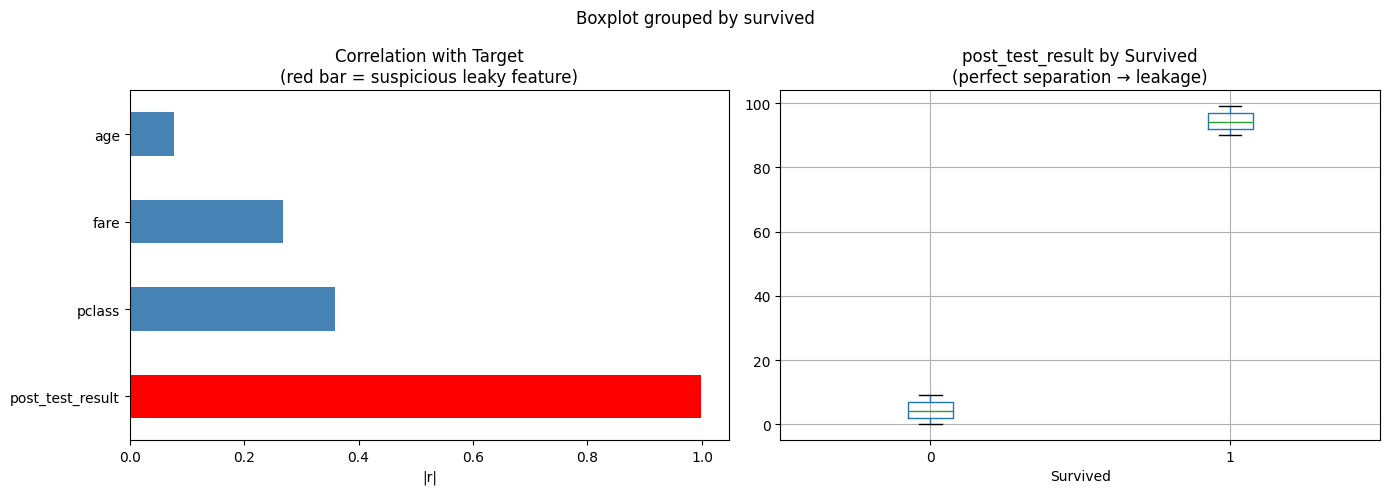

In [4]:
# The leaky feature shows near-perfect correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_with_target.plot(kind='barh', ax=axes[0], color=['red' if f == 'post_test_result' else 'steelblue'
                                                        for f in corr_with_target.index])
axes[0].set_title('Correlation with Target\n(red bar = suspicious leaky feature)')
axes[0].set_xlabel('|r|')

# Scatter: leaky feature vs survived — near perfect separation
df_model.boxplot(column='post_test_result', by='survived', ax=axes[1])
axes[1].set_title('post_test_result by Survived\n(perfect separation → leakage)')
axes[1].set_xlabel('Survived')

plt.tight_layout()
plt.show()

---
## Leakage in Time-Series Data

For time-ordered data, the split must respect time — never randomly shuffle.

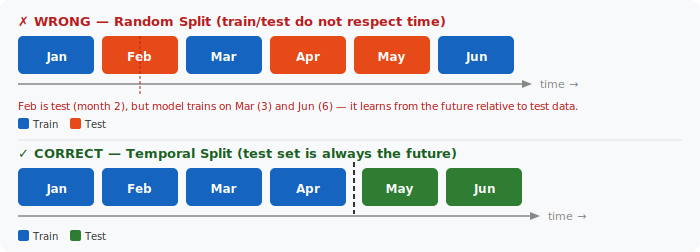

In [5]:
from IPython.display import SVG, display

_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="252"
     font-family="'Segoe UI', Arial, sans-serif">

  <!-- background -->
  <rect width="700" height="252" fill="#f8f9fa" rx="10"/>

  <!-- ══════════════════════════════════════════════
       WRONG — random split
       Train: Jan Mar Jun   |   Test: Feb Apr May
       Shown in chronological position to expose the problem
       ══════════════════════════════════════════════ -->

  <text x="18" y="26" fill="#B71C1C" font-size="13" font-weight="bold">
    ✗  WRONG — Random Split (train/test do not respect time)</text>

  <!-- Chronological month positions, mixed colours -->
  <!-- Jan(train) -->
  <rect x="18"  y="36" width="76" height="38" rx="5" fill="#1565C0"/>
  <text x="56"  y="61" text-anchor="middle" fill="white" font-size="12" font-weight="bold">Jan</text>

  <!-- Feb(test) — a test month sandwiched between train months -->
  <rect x="102" y="36" width="76" height="38" rx="5" fill="#E64A19"/>
  <text x="140" y="61" text-anchor="middle" fill="white" font-size="12" font-weight="bold">Feb</text>

  <!-- Mar(train) -->
  <rect x="186" y="36" width="76" height="38" rx="5" fill="#1565C0"/>
  <text x="224" y="61" text-anchor="middle" fill="white" font-size="12" font-weight="bold">Mar</text>

  <!-- Apr(test) -->
  <rect x="270" y="36" width="76" height="38" rx="5" fill="#E64A19"/>
  <text x="308" y="61" text-anchor="middle" fill="white" font-size="12" font-weight="bold">Apr</text>

  <!-- May(test) -->
  <rect x="354" y="36" width="76" height="38" rx="5" fill="#E64A19"/>
  <text x="392" y="61" text-anchor="middle" fill="white" font-size="12" font-weight="bold">May</text>

  <!-- Jun(train) — a train month that comes AFTER several test months -->
  <rect x="438" y="36" width="76" height="38" rx="5" fill="#1565C0"/>
  <text x="476" y="61" text-anchor="middle" fill="white" font-size="12" font-weight="bold">Jun</text>

  <!-- Time axis -->
  <line x1="18" y1="84" x2="522" y2="84" stroke="#888" stroke-width="1.5"/>
  <polygon points="522,80 532,84 522,88" fill="#888"/>
  <text x="540" y="88" fill="#888" font-size="11">time →</text>

  <!-- Problem callout -->
  <line x1="140" y1="36" x2="140" y2="96" stroke="#B71C1C" stroke-width="1" stroke-dasharray="3,2"/>
  <text x="18" y="110" fill="#B71C1C" font-size="10.5">
    Feb is test (month 2), but model trains on Mar (3) and Jun (6) — it learns from the future relative to test data.</text>

  <!-- Legend -->
  <rect x="18" y="118" width="11" height="11" fill="#1565C0" rx="2"/>
  <text x="33" y="128" fill="#333" font-size="10">Train</text>
  <rect x="70" y="118" width="11" height="11" fill="#E64A19" rx="2"/>
  <text x="85" y="128" fill="#333" font-size="10">Test</text>

  <!-- divider -->
  <line x1="18" y1="140" x2="682" y2="140" stroke="#dee2e6" stroke-width="1"/>

  <!-- ══════════════════════════════════════════════
       CORRECT — temporal split
       Train: Jan Feb Mar Apr   |   Test: May Jun
       ══════════════════════════════════════════════ -->

  <text x="18" y="158" fill="#1B5E20" font-size="13" font-weight="bold">
    ✓  CORRECT — Temporal Split (test set is always the future)</text>

  <!-- Jan(train) -->
  <rect x="18"  y="168" width="76" height="38" rx="5" fill="#1565C0"/>
  <text x="56"  y="193" text-anchor="middle" fill="white" font-size="12" font-weight="bold">Jan</text>

  <!-- Feb(train) -->
  <rect x="102" y="168" width="76" height="38" rx="5" fill="#1565C0"/>
  <text x="140" y="193" text-anchor="middle" fill="white" font-size="12" font-weight="bold">Feb</text>

  <!-- Mar(train) -->
  <rect x="186" y="168" width="76" height="38" rx="5" fill="#1565C0"/>
  <text x="224" y="193" text-anchor="middle" fill="white" font-size="12" font-weight="bold">Mar</text>

  <!-- Apr(train) -->
  <rect x="270" y="168" width="76" height="38" rx="5" fill="#1565C0"/>
  <text x="308" y="193" text-anchor="middle" fill="white" font-size="12" font-weight="bold">Apr</text>

  <!-- split line -->
  <line x1="354" y1="162" x2="354" y2="214" stroke="#333" stroke-width="2" stroke-dasharray="5,3"/>

  <!-- May(test) -->
  <rect x="362" y="168" width="76" height="38" rx="5" fill="#2E7D32"/>
  <text x="400" y="193" text-anchor="middle" fill="white" font-size="12" font-weight="bold">May</text>

  <!-- Jun(test) -->
  <rect x="446" y="168" width="76" height="38" rx="5" fill="#2E7D32"/>
  <text x="484" y="193" text-anchor="middle" fill="white" font-size="12" font-weight="bold">Jun</text>

  <!-- Time axis -->
  <line x1="18" y1="216" x2="530" y2="216" stroke="#888" stroke-width="1.5"/>
  <polygon points="530,212 540,216 530,220" fill="#888"/>
  <text x="548" y="220" fill="#888" font-size="11">time →</text>

  <!-- Legend -->
  <rect x="18" y="230" width="11" height="11" fill="#1565C0" rx="2"/>
  <text x="33" y="240" fill="#333" font-size="10">Train</text>
  <rect x="70" y="230" width="11" height="11" fill="#2E7D32" rx="2"/>
  <text x="85" y="240" fill="#333" font-size="10">Test</text>
</svg>"""

display(SVG(_svg))

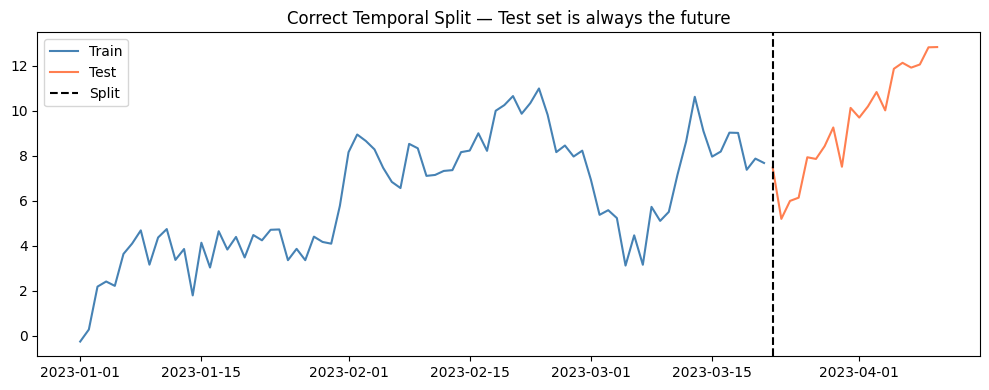

In [6]:
dates = pd.date_range('2023-01-01', periods=100, freq='D')
ts_df = pd.DataFrame({'date': dates, 'value': np.cumsum(np.random.randn(100))})

# Correct time-based split
split_idx = int(len(ts_df) * 0.8)
train_ts = ts_df.iloc[:split_idx]
test_ts  = ts_df.iloc[split_idx:]

plt.figure(figsize=(10, 4))
plt.plot(train_ts['date'], train_ts['value'], color='steelblue', label='Train')
plt.plot(test_ts['date'],  test_ts['value'],  color='coral',      label='Test')
plt.axvline(ts_df.iloc[split_idx]['date'], color='black', linestyle='--', label='Split')
plt.title('Correct Temporal Split — Test set is always the future')
plt.legend()
plt.tight_layout()
plt.show()

## Leakage Prevention Checklist

| Check | Question |
|---|---|
| Temporal order | Is the split chronological for time-series data? |
| Feature timing | Is every feature known *before* the prediction is made? |
| Preprocessing order | Are scalers/imputers fit on train only? |
| Correlation audit | Do any features have suspiciously high correlation with the target? |
| Cross-validation | Is CV performed correctly (no group or time leakage across folds)? |

**Warning sign**: if your model performs far better in validation than in production, suspect leakage first.